# Motor Current Histogram

**Author:** Jonah Lee

**Date:** 2025-10-25

**Relevant Links:**
- N/A (this was a one-off request)


## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [24]:
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt
from data_tools import query, FSGPDayLaps, TimeSeries

## Data Acquisition

Obtain the data relevant to this analysis. Load data from saved files, or query it directly.

In [19]:
client = query.DBClient()

fields = ('BatteryCurrent', 'VehicleVelocity')
data: dict[int, dict[str, TimeSeries]] = {}

for day in (1, 3):
    race_day = FSGPDayLaps(day)
    start = race_day.get_start_utc(1)
    last_lap = race_day.get_lap_count()
    stop = race_day.get_finish_utc(last_lap)

    day_data = {}
    for field in fields:
        day_data[field] = client.query_time_series(start, stop, field)

    data[day] = day_data

## Analysis

Compute the desired results and present them. Take advantage of Markdown cells to guide the reader through your derivation process.

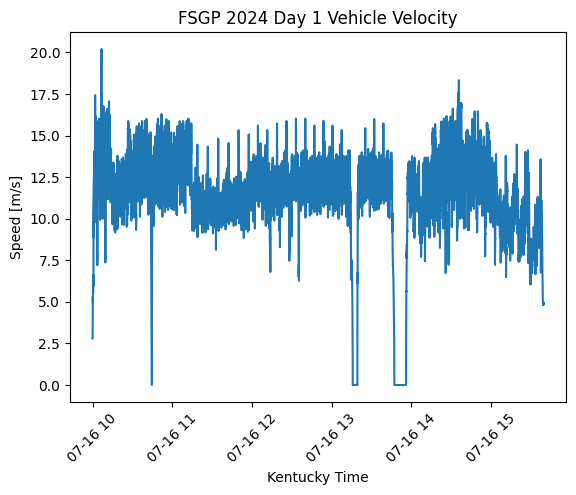

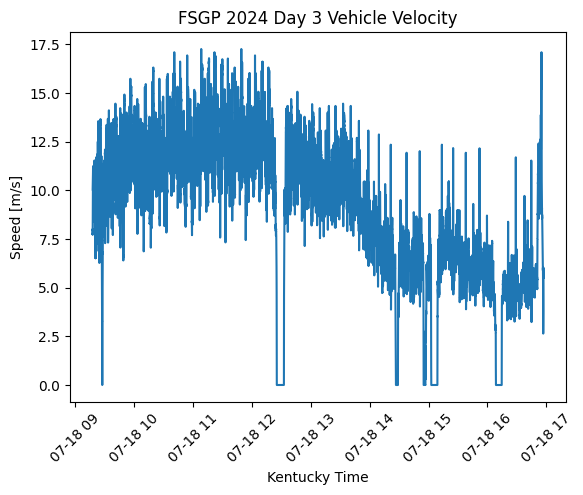

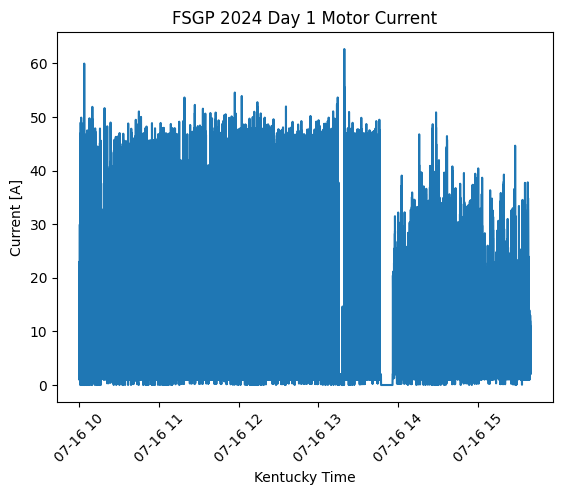

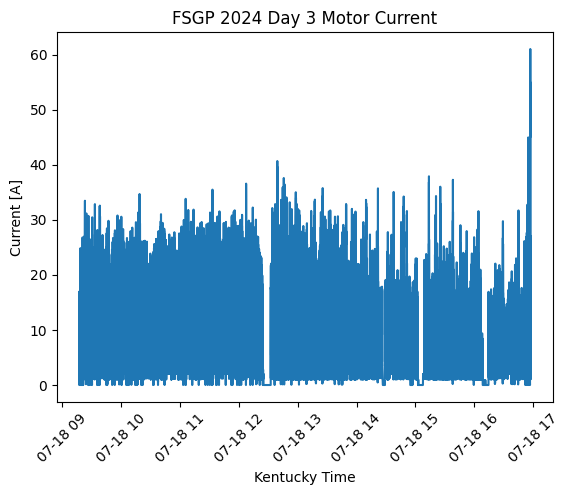

In [25]:
vancouver_to_kentucky_time: timedelta = timedelta(hours=2)

for day, day_data in data.items():
    speed_mps = day_data['VehicleVelocity']
    plt.plot(speed_mps.datetime_x_axis + vancouver_to_kentucky_time, speed_mps)
    plt.title(f"FSGP 2024 Day {day} Vehicle Velocity")
    plt.xlabel("Kentucky Time")
    plt.ylabel("Speed [m/s]")
    plt.xticks(rotation=45)
    plt.show()

for day, day_data in data.items():
    current = day_data['BatteryCurrent']
    plt.plot(current.datetime_x_axis + vancouver_to_kentucky_time, current)
    plt.title(f"FSGP 2024 Day {day} Motor Current")
    plt.xlabel("Kentucky Time")
    plt.ylabel("Current [A]")
    plt.xticks(rotation=45)
    plt.show()

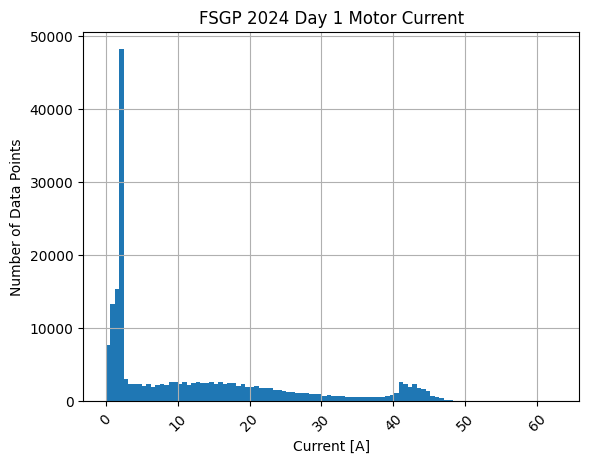

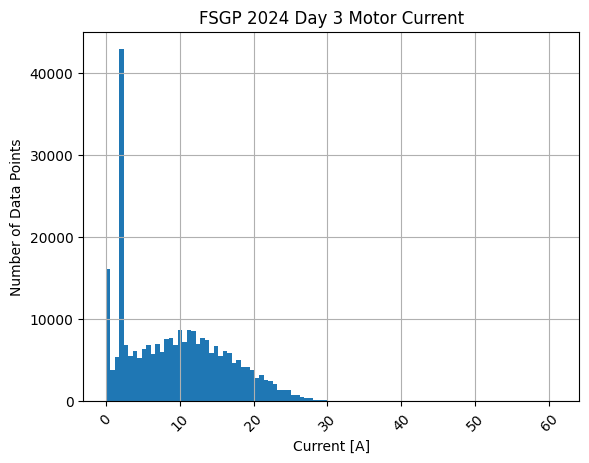

In [26]:
for day, day_data in data.items():
    current = day_data['BatteryCurrent']
    plt.hist(current, bins=100)
    plt.title(f"FSGP 2024 Day {day} Motor Current")
    plt.xlabel("Current [A]")
    plt.ylabel("Number of Data Points")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

In [33]:
driver_currents: dict[str, list[TimeSeries]] = {}

for day in (1, 3):
    race_day = FSGPDayLaps(day)

    for lap_idx in range(race_day.get_lap_count()):
        lap = lap_idx + 1
        driver = race_day.get_lap_driver(lap)

        start = race_day.get_start_utc(lap)
        stop = race_day.get_finish_utc(lap)
        if driver not in driver_currents:
            driver_currents[driver] = []
        driver_currents[driver].append(
            client.query_time_series(start, stop, 'BatteryCurrent')
        )

        data[day] = day_data

In [34]:
driver_currents_joined = {}
for driver, laps in driver_currents.items():
    driver_currents_joined[driver] = np.concatenate([lap_data for lap_data in laps])

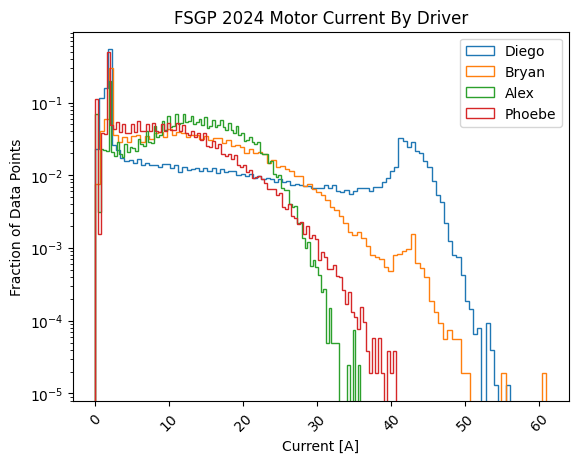

In [44]:

for driver, all_current_data in driver_currents_joined.items():
    plt.hist(all_current_data, bins=100, histtype='step', label=driver, density=True)
    plt.title(f"FSGP 2024 Motor Current By Driver")
    plt.xlabel("Current [A]")
    plt.ylabel("Fraction of Data Points")
    plt.xticks(rotation=45)
    plt.grid()
plt.legend(loc='best')
plt.yscale('log')
plt.show()